In [55]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import numpy as np

In [56]:
dataset_name = "samsung"

In [57]:
df=pd.read_csv(f"../data/raw/{dataset_name}_clean.csv")

In [58]:
df.head()


,Date,Open,High,Low,Close,Volume,Asset_Name
0,2000-01-04,6000.0,6110.0,5660.0,6110.0,74195000,Samsung
1,2000-01-05,5800.0,6060.0,5520.0,5580.0,74680000,Samsung
2,2000-01-06,5750.0,5780.0,5580.0,5620.0,54390000,Samsung
3,2000-01-07,5560.0,5670.0,5360.0,5540.0,40305000,Samsung
4,2000-01-10,5600.0,5770.0,5580.0,5770.0,46880000,Samsung


In [59]:
df["Date"] = pd.to_datetime(
    df["Date"]
)

In [60]:
df.isnull().sum()

Date          0
Open          0
High          0
Low           0
Close         0
Volume        0
Asset_Name    0
dtype: int64

In [61]:
print("Dataset Shape:", df.shape)

Dataset Shape: (6412, 7)


In [62]:
print("Columns:")
print(df.columns)

Columns:
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'Asset_Name'], dtype='str')


In [63]:
print(df.describe())

                             Date          Open          High           Low  \
count                        6412   6412.000000   6412.000000   6412.000000   
mean   2012-08-25 20:34:57.567061  29903.126949  30198.761697  29599.502495   
min           2000-01-04 00:00:00   2540.000000   2760.000000   2420.000000   
25%           2006-02-27 18:00:00  10975.000000  11100.000000  10840.000000   
50%           2012-07-24 12:00:00  23440.000000  23670.000000  23150.000000   
75%           2019-02-02 12:00:00  48245.000000  48920.000000  47700.000000   
max           2025-08-14 00:00:00  90300.000000  96800.000000  89500.000000   
std                           NaN  23294.571748  23487.510108  23085.939023   

              Close        Volume  
count   6412.000000  6.412000e+03  
mean   29891.837180  2.115096e+07  
min     2730.000000  0.000000e+00  
25%    10980.000000  1.177959e+07  
50%    23430.000000  1.724338e+07  
75%    48320.000000  2.608781e+07  
max    91000.000000  1.642150e+08  


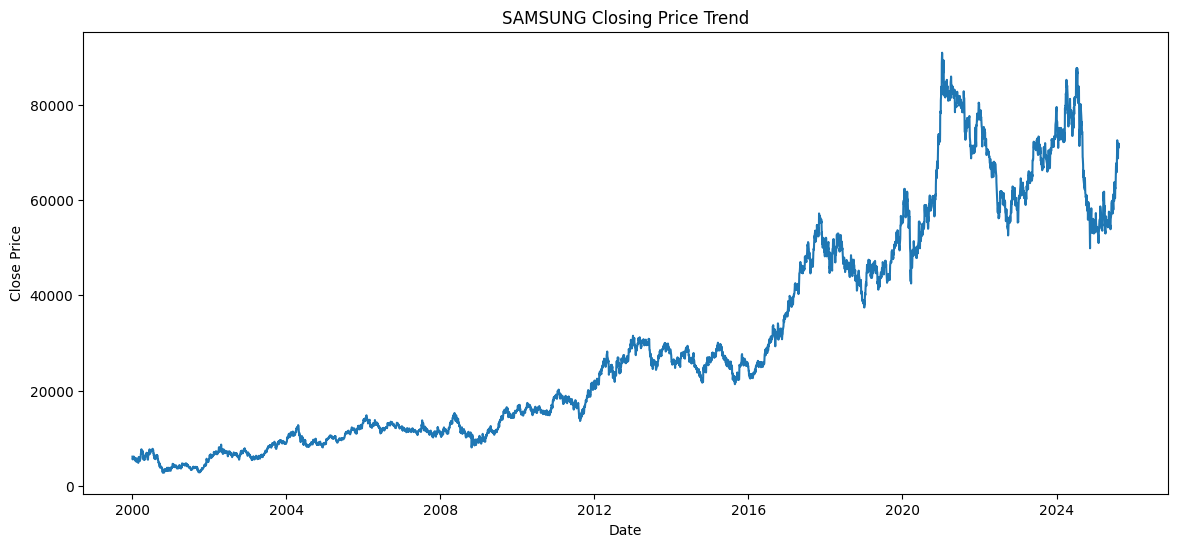

In [64]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Close"]
)

plt.title(
    f"{dataset_name.upper()} Closing Price Trend"
)

plt.xlabel("Date")

plt.ylabel("Close Price")

plt.show()

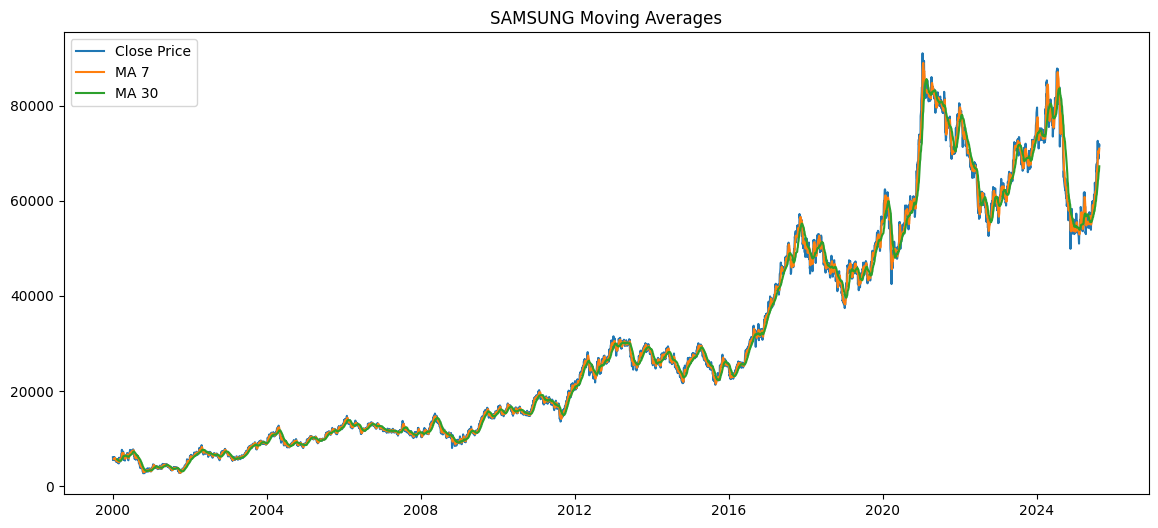

In [65]:
df["MA_7"] = (
    df["Close"]
    .rolling(window=7)
    .mean()
)
df["MA_30"] = (
    df["Close"]
    .rolling(window=30)
    .mean()
)


plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Close"],
    label="Close Price"
)

plt.plot(
    df["Date"],
    df["MA_7"],
    label="MA 7"
)

plt.plot(
    df["Date"],
    df["MA_30"],
    label="MA 30"
)

plt.title(
    f"{dataset_name.upper()} Moving Averages"
)

plt.legend()

plt.show()

In [66]:
df["Daily_Return"] = (
    df["Close"].pct_change()
)

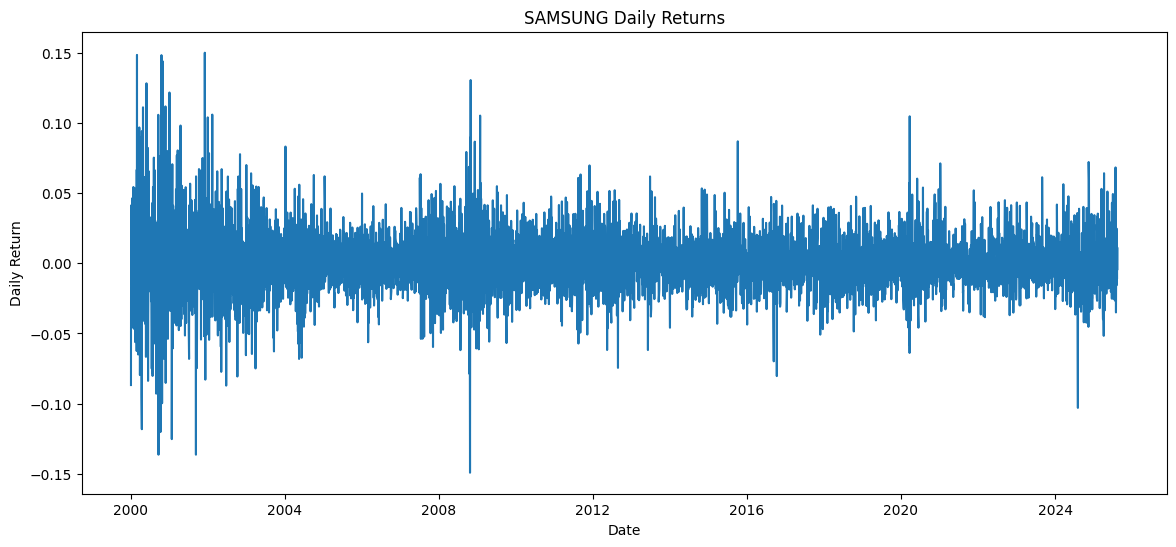

In [67]:
plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Daily_Return"]
)

plt.title(
    f"{dataset_name.upper()} Daily Returns"
)

plt.xlabel("Date")

plt.ylabel("Daily Return")

plt.show()

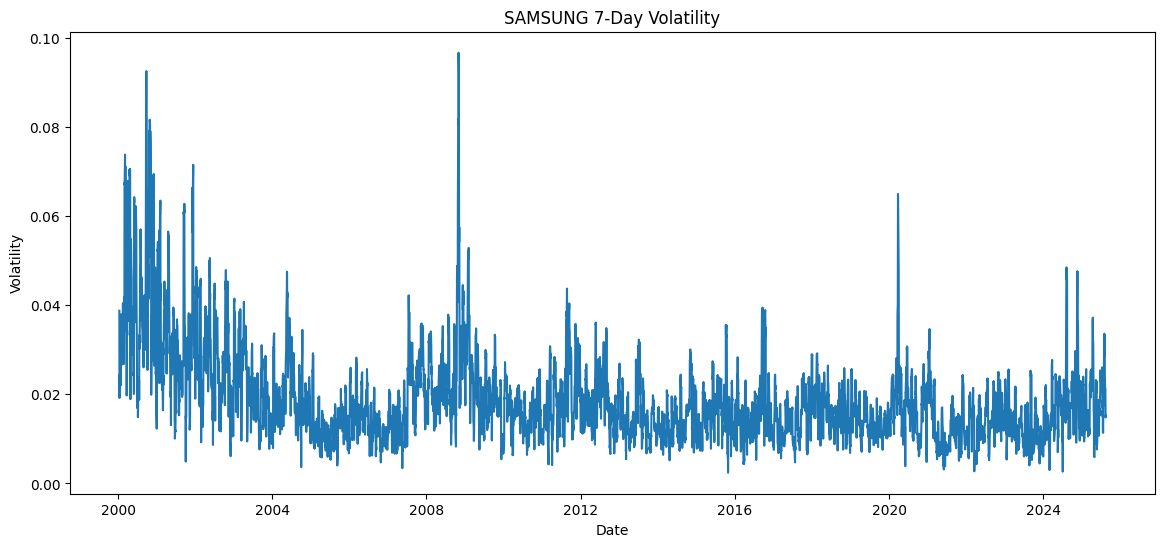

In [68]:
df["Volatility_7"] = (
    df["Daily_Return"]
    .rolling(window=7)
    .std()
)

plt.figure(figsize=(14,6))

plt.plot(
    df["Date"],
    df["Volatility_7"]
)

plt.title(
    f"{dataset_name.upper()} 7-Day Volatility"
)

plt.xlabel("Date")

plt.ylabel("Volatility")

plt.show()

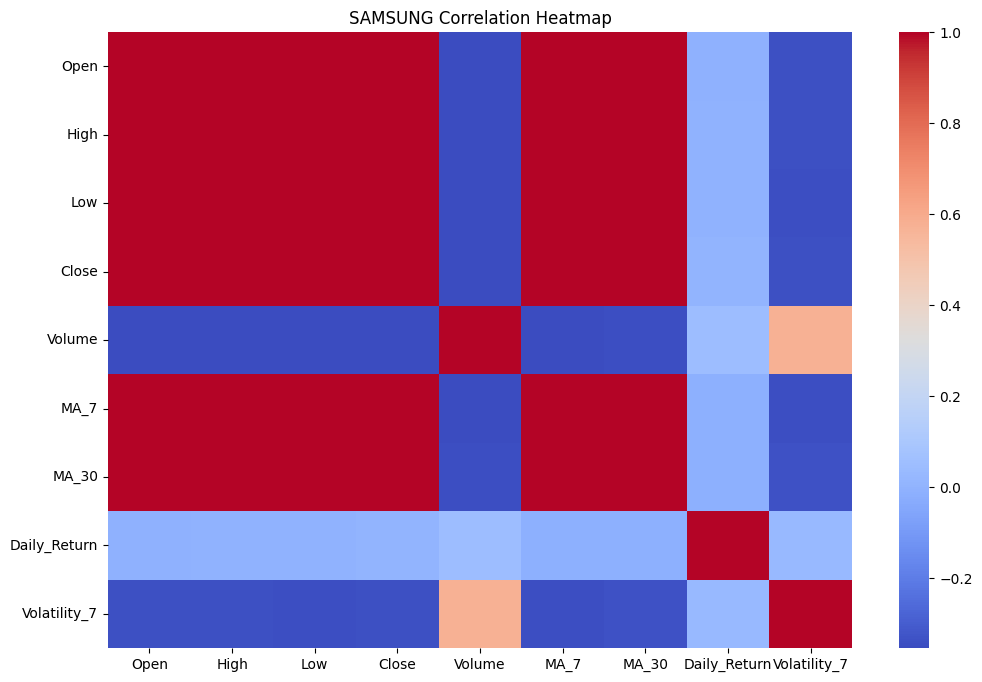

In [69]:
numeric_df = df.select_dtypes(
    include=["number"]
)
corr_matrix = numeric_df.corr()

plt.figure(figsize=(12,8))

sb.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title(
    f"{dataset_name.upper()} Correlation Heatmap"
)

plt.show()

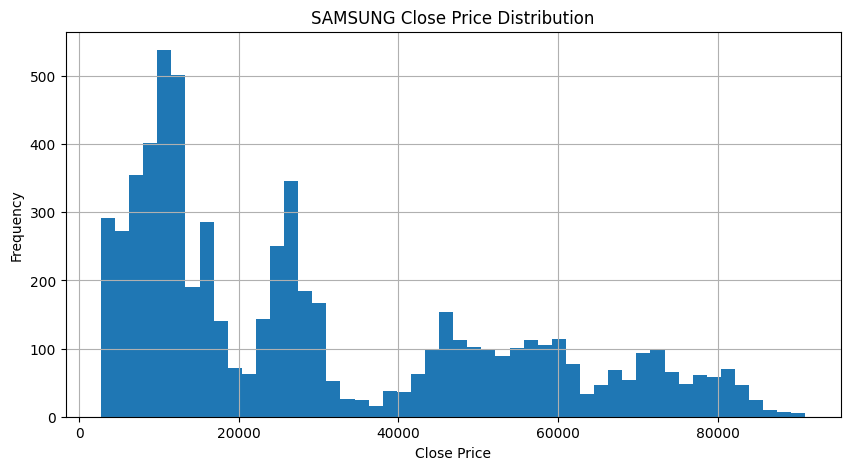

In [70]:
plt.figure(figsize=(10,5))

df["Close"].hist(
    bins=50
)

plt.title(
    f"{dataset_name.upper()} Close Price Distribution"
)

plt.xlabel("Close Price")

plt.ylabel("Frequency")

plt.show()

In [71]:
df.duplicated().sum()

np.int64(0)

In [72]:
df.to_csv(
    f"../data/processed/{dataset_name}_eda.csv",
    index=False
)